## Build a system that converts raw IPL JSON → structured dataset → insights → ML predictions.

### Raw JSON → Extraction → Cleaning → Feature Engineering → EDA → ML → Prediction

In [36]:
from pathlib import Path
import json
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
#from sklearn.metrics import


In [13]:
# Data Extraction from json to Data Frame
# Selecting the required Columns for easy access the Data

data = []

folder = Path("ipl_json")

for file in folder.glob("*.json"):
    with open(file) as f:
        match = json.load(f)

    info = match["info"]
    teams = info["teams"]
    winner = info.get("outcome", {}).get("winner")

    for inning in match["innings"]:
        batting_team = inning["team"]

        for over in inning["overs"]:
            over_no = over["over"]

            for ball in over["deliveries"]:
                data.append({
                    "batter": ball["batter"],
                    "bowler": ball["bowler"],
                    "runs": ball["runs"]["total"],
                    "batter_runs": ball["runs"]["batter"],
                    "extras": ball["runs"]["extras"],
                    "over": over_no,
                    "batting_team": batting_team,
                    "winner": winner
                })

df = pd.DataFrame(data)

In [37]:
# Checking the Data Frame for understand the Data and it's type, shape like no of rows

df.head()

,batter,bowler,runs,batter_runs,extras,over,batting_team,winner,valid_ball,phase,is_four,is_six
0,DA Warner,TS Mills,0,0,0,0,Sunrisers Hyderabad,Sunrisers Hyderabad,True,Powerplay,0,0
1,DA Warner,TS Mills,0,0,0,0,Sunrisers Hyderabad,Sunrisers Hyderabad,True,Powerplay,0,0
2,DA Warner,TS Mills,4,4,0,0,Sunrisers Hyderabad,Sunrisers Hyderabad,True,Powerplay,1,0
3,DA Warner,TS Mills,0,0,0,0,Sunrisers Hyderabad,Sunrisers Hyderabad,True,Powerplay,0,0
4,DA Warner,TS Mills,2,0,2,0,Sunrisers Hyderabad,Sunrisers Hyderabad,False,Powerplay,0,0


In [24]:
# Checking the Null values in DataFrame
# Winner column have the Null values, as per my understanding the Data those matches are tie and some are cancelled abnormally due to rain

df.isnull().sum()

batter          0
bowler          0
runs            0
batter_runs     0
extras          0
over            0
batting_team    0
winner          0
dtype: int64

In [20]:
# Checking the Columns Data types
# they are majorly two data types Object and Int64 type

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282974 entries, 0 to 282973
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   batter        282974 non-null  object
 1   bowler        282974 non-null  object
 2   runs          282974 non-null  int64 
 3   batter_runs   282974 non-null  int64 
 4   extras        282974 non-null  int64 
 5   over          282974 non-null  int64 
 6   batting_team  282974 non-null  object
 7   winner        278250 non-null  object
dtypes: int64(4), object(4)
memory usage: 17.3+ MB


In [25]:
# Data Cleaning
# Handling the missing values in Winner column, filling with tie values

df['winner'] = df['winner'].fillna('tie')

In [26]:
# Feature Engineering
# Adding the new as valid_ball column bases on batter_runs and extras

df["valid_ball"] = ~((df["batter_runs"] == 0) & (df["extras"] > 0))

In [27]:
# Match Phases

def phase(over):
    if over <= 6:
        return "Powerplay"
    elif over <= 15:
        return "Middle"
    else:
        return "Death"


In [28]:
# Phase Column (Match Phases)

df["phase"] = df["over"].apply(phase)

In [30]:
# Boundary Features

df["is_four"] = (df["batter_runs"] == 4).astype(int)
df["is_six"] = (df["batter_runs"] == 6).astype(int)

### EDA (Exploratory Data Analysis)

<Axes: title={'center': 'Top Batsmen'}, xlabel='batter'>

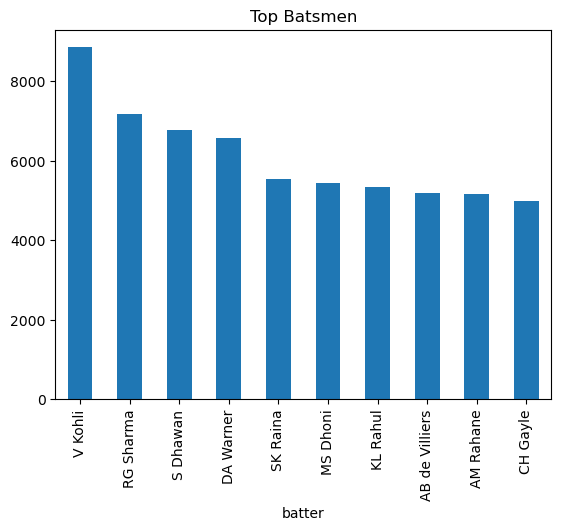

In [32]:
# Top Batsman

batsman = df.groupby("batter")["batter_runs"].sum().sort_values(ascending=False).head(10)

batsman.plot(kind="bar", title="Top Batsmen")

<Axes: title={'center': 'Average Runs by Phase'}, xlabel='phase'>

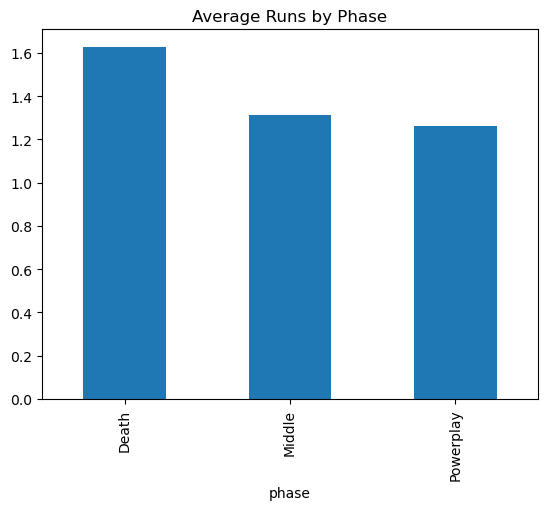

In [33]:
# Runs as per Phase

phase_runs = df.groupby("phase")["runs"].mean()

phase_runs.plot(kind="bar", title="Average Runs by Phase")

<Axes: title={'center': 'Boundary Count'}>

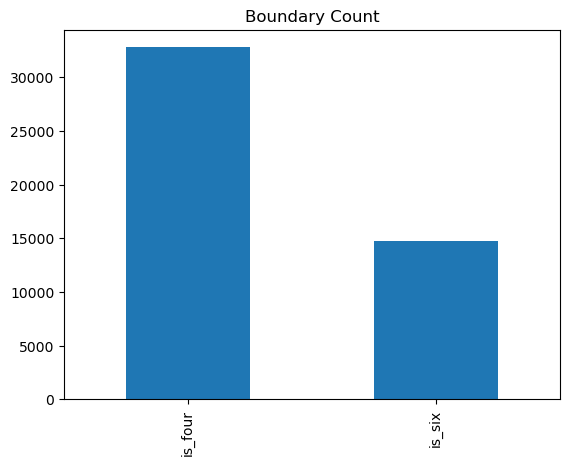

In [34]:
# Boundary Anaylysis

df[["is_four","is_six"]].sum().plot(kind="bar", title="Boundary Count")

### ML Prediction Winner

In [38]:
# Prepare the Data

le = LabelEncoder()

df["batting_team_enc"] = le.fit_transform(df["batting_team"])
df["winner_enc"] = le.fit_transform(df["winner"])

In [50]:
df[["batting_team","batting_team_enc"]].drop_duplicates().sort_values("batting_team_enc")

,batting_team,batting_team_enc
13984,Chennai Super Kings,0
147314,Deccan Chargers,1
28606,Delhi Capitals,2
1084,Delhi Daredevils,3
495,Gujarat Lions,4
72297,Gujarat Titans,5
838,Kings XI Punjab,6
188450,Kochi Tuskers Kerala,7
617,Kolkata Knight Riders,8
72173,Lucknow Super Giants,9


In [51]:
df[["winner","winner_enc"]].drop_duplicates().sort_values("winner_enc")

,winner,winner_enc
13862,Chennai Super Kings,0
149215,Deccan Chargers,1
28606,Delhi Capitals,2
1890,Delhi Daredevils,3
2832,Gujarat Lions,4
72173,Gujarat Titans,5
713,Kings XI Punjab,6
190818,Kochi Tuskers Kerala,7
495,Kolkata Knight Riders,8
72909,Lucknow Super Giants,9


In [39]:
match_df = df.groupby("batting_team").agg({
    "runs": "sum"
}).reset_index()

In [40]:
match_df

,batting_team,runs
0,Chennai Super Kings,41825
1,Deccan Chargers,11463
2,Delhi Capitals,18107
3,Delhi Daredevils,24296
4,Gujarat Lions,4862
5,Gujarat Titans,11390
6,Kings XI Punjab,30064
7,Kochi Tuskers Kerala,1901
8,Kolkata Knight Riders,41920
9,Lucknow Super Giants,10889


In [41]:
X = df[["over", "runs", "batting_team_enc"]]
y = df["winner_enc"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.4794946550048591


In [59]:
sample = [[15, 10, 4]]  # over, runs, team

prediction = model.predict(sample)
print("Predicted Winner:", prediction)

Predicted Winner: [6]


E:\Program files\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [45]:
le.inverse_transform([5])

array(['Gujarat Titans'], dtype=object)

### Key Challenges Solved
- Handling nested JSON data
- Managing missing winner values
- Correctly identifying valid balls
- Handling extras and super overs
- Converting categorical data for ML

### Outcome / Impact
- Built end-to-end pipeline
- Generated player & team insights
- Created predictive model for match outcomes